<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print("Distribuicao das classes no treino:")
print(y_train.value_counts(normalize=True).sort_index())
print("Distribuicao das classes no teste:")
print(y_test.value_counts(normalize=True).sort_index())

Formato de X_train: (105, 4)
Formato de X_test: (45, 4)
Distribuicao das classes no treino:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64
Distribuicao das classes no teste:
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Acuracia no treino: {train_acc:.4f}")
print(f"Acuracia no teste:  {test_acc:.4f}")

Acuracia no treino: 1.0000
Acuracia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

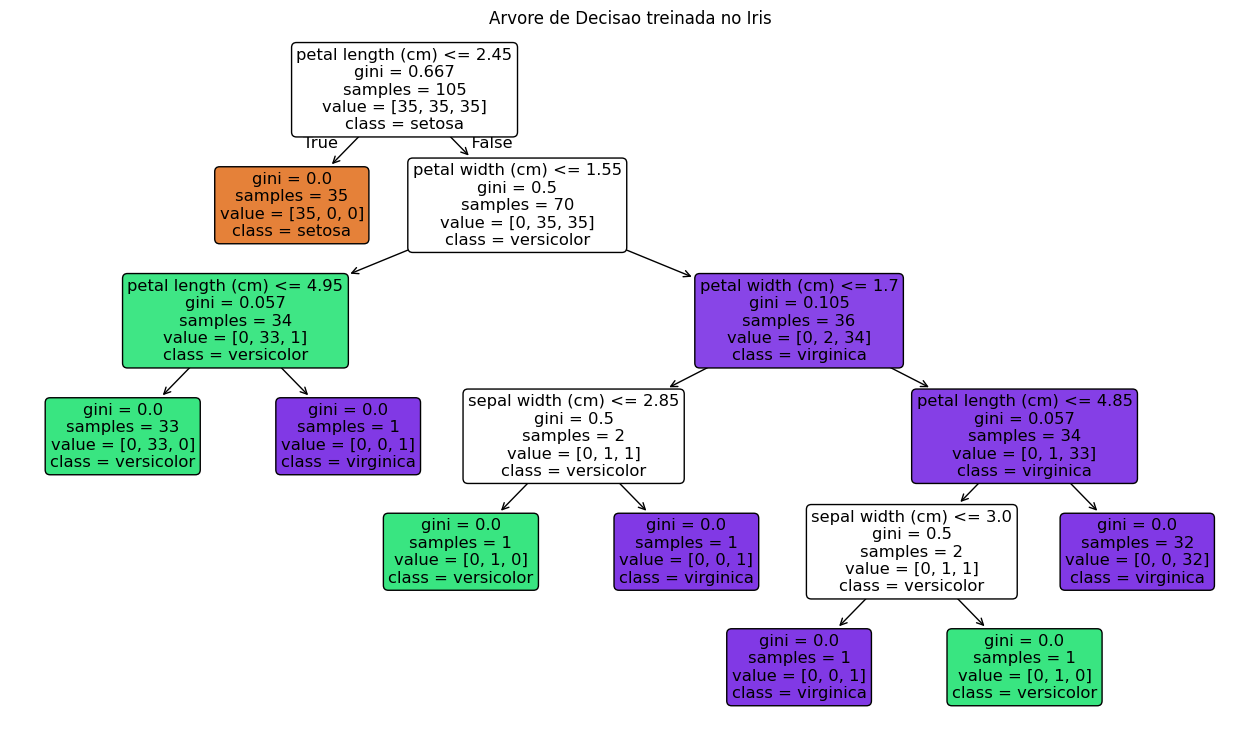

Atributo na raiz: petal length (cm)
Profundidade da arvore: 5


In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 9))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
)
plt.title("Arvore de Decisao treinada no Iris")
plt.show()

root_feature_index = dt_model.tree_.feature[0]
root_feature_name = feature_names[root_feature_index]
tree_depth = dt_model.get_depth()

print(f"Atributo na raiz: {root_feature_name}")
print(f"Profundidade da arvore: {tree_depth}")

1. O atributo na raiz aparece no "root_feature_name".
2. A profundidade da arvore tambem aparece no "tree_depth".

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [10]:
depth_values = list(range(1, 10)) + [None]
rows = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    rows.append(
        {
            "max_depth": depth,
            "train_accuracy": train_score,
            "test_accuracy": test_score,
            "tree_depth": model.get_depth(),
            "num_leaves": model.get_n_leaves(),
        }
    )

depth_results = pd.DataFrame(rows)
depth_results

,max_depth,train_accuracy,test_accuracy,tree_depth,num_leaves
0,1.0,0.666667,0.666667,1,2
1,2.0,0.971429,0.888889,2,3
2,3.0,0.980952,0.977778,3,5
3,4.0,0.990476,0.888889,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,NaN,1.000000,0.933333,5,8


**Em qual profundidade comeca o overfitting?**  
Observando a tabela, o overfitting comeca quando a acuracia de treino continua subindo enquanto a de teste para de melhorar ou cai.

**Por que a arvore consegue 100% no treino quando "max_depth=None"?**  
Sem limite de profundidade, a arvore pode criar muitas regras para separar quase perfeitamente os exemplos de treino, memorizando o conjunto de treino.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [15]:
criteria = ["gini", "entropy"]
criterion_rows = []

for criterion in criteria:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)

    criterion_rows.append(
        {
            "criterion": criterion,
            "tree_depth": model.get_depth(),
            "train_accuracy": model.score(X_train, y_train),
            "test_accuracy": model.score(X_test, y_test),
        }
    )

criterion_results = pd.DataFrame(criterion_rows)
criterion_results

,criterion,tree_depth,train_accuracy,test_accuracy
0,gini,5,1.0,0.933333
1,entropy,6,1.0,0.888889


**Comparacao (Q5)**

Comparando os dois criterios com os resultados da tabela:

- O criterio gini gerou arvore com profundidade **5**.
- O criterio entropy gerou arvore com profundidade **6**.
- A acuracia de treino ficou igual nos dois casos (**1.0000**).
- A acuracia de teste foi maior com gini (**0.9333**) do que com entropy (**0.8889**).

Conclusao: nesta divisao dos dados, gini foi melhor para generalizacao, com ganho aproximado de **0.0444** na acuracia de teste e com menor complexidade da arvore.

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [16]:
candidate_depths = [1, 2, 3, 4, 5, 6, 7, None]
exp_rows = []

for depth in candidate_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    exp_rows.append(
        {
            "max_depth": depth,
            "train_accuracy": model.score(X_train, y_train),
            "test_accuracy": model.score(X_test, y_test),
            "tree_depth": model.get_depth(),
            "num_leaves": model.get_n_leaves(),
        }
    )

experiment_df = pd.DataFrame(exp_rows)
experiment_df = experiment_df.sort_values("max_depth", key=lambda s: s.map(lambda v: 999 if v is None else v))

best_idx = experiment_df["test_accuracy"].idxmax()
best_row = experiment_df.loc[best_idx]

print("Melhor configuracao encontrada:")
print(f"- max_depth: {best_row['max_depth']}")
print(f"- acuracia de treino: {best_row['train_accuracy']:.4f}")
print(f"- acuracia de teste:  {best_row['test_accuracy']:.4f}")
print(f"- profundidade final da arvore: {int(best_row['tree_depth'])}")
print(f"- numero de folhas: {int(best_row['num_leaves'])}")

experiment_df

Melhor configuracao encontrada:
- max_depth: 3.0
- acuracia de treino: 0.9810
- acuracia de teste:  0.9778
- profundidade final da arvore: 3
- numero de folhas: 5


,max_depth,train_accuracy,test_accuracy,tree_depth,num_leaves
0,1.0,0.666667,0.666667,1,2
1,2.0,0.971429,0.888889,2,3
2,3.0,0.980952,0.977778,3,5
3,4.0,0.990476,0.888889,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,NaN,1.000000,0.933333,5,8


**Interpretacao (Q6)**

A variacao de max_depth mostrou claramente o equilibrio entre capacidade de ajuste e capacidade de generalizacao:

- Em max_depth=1, treino e teste ficaram em **0.6667**. Isso indica underfitting, porque o modelo e simples demais para separar bem as classes.
- Em max_depth=None, o treino chega a **1.0000**, mas o teste fica em **0.9333**. A diferenca entre o desempenho no treino e no teste aumenta, sinal de maior variancia e risco de overfitting.
- O melhor equilibrio apareceu em max_depth=3, com **0.9810** no treino e **0.9778** no teste. A diferenca entre treino e teste e pequena e a acuracia de teste foi a maior observada.

Conclusao: para esse conjunto e essa divisao, a melhor escolha foi a arvore com max_depth=3, pois alcancou o melhor resultado em teste sem aumentar a complexidade de forma desnecessaria.